# IMC 2025 - Clustering Stage Only

This notebook implements **only** the **clustering stage** for the Kaggle **Image Matching Challenge 2025**.

**Goal**: given `DATA_ROOT`, produce a `pandas.DataFrame` with columns `[dataset, image_id, scene]` where:
- `scene` is a deterministic label `cluster_0001`, `cluster_0002`, …
- images classified as outliers use the exact label **`outliers`**

No pose estimation / SfM is performed.


## 0) Configuration

All important knobs live here.

Precision/recall trade-offs:
- Higher `K` / lower thresholds → more edges → fewer outliers but higher risk of merging scenes.
- Lower `K` / stricter RANSAC → fewer false edges but risk fragmenting scenes.

Everything is cached under `./cache/` so re-runs are much faster.


In [43]:
from pathlib import Path

# --- Paths ---
DATA_ROOT = Path("./data/train")
CACHE_ROOT = Path("./cache")

# --- Image policy ---
MATCH_LONG_SIDE = 1024            # resized long side for local features + RANSAC
SAVE_RESIZED_CACHE = False        # optional: cache resized images under cache/{dataset}/resized_{MATCH_LONG_SIDE}/

# --- Retrieval embeddings (avoid O(N^2) matching) ---
EMBED_MODEL_PREFERENCE = [
    # Preferred: DINOv2 (if present in timm *and* weights available offline)
    "vit_base_patch14_dinov2.lvd142m",
    "vit_small_patch14_dinov2.lvd142m",
    # Fallbacks
    "vit_base_patch16_224.augreg_in21k",
    "vit_small_patch16_224.augreg_in21k",
    "resnet50.a1_in1k",
]
EMBED_BATCH_SIZE = 32

# If pretrained weights cannot be loaded offline, use a deterministic handcrafted global descriptor.
ALLOW_HANDCRAFTED_EMBED_FALLBACK = True

# --- Candidate pairs ---
K = 30                           # top-K neighbors per image
MUTUAL_ONLY = True               # keep only mutual-KNN edges (high precision)
EXTRA_NON_MUTUAL = 0             # optionally add some non-mutual edges for recall

# --- Local matching + geometric verification ---
MIN_INLIERS = 30
MIN_INLIER_RATIO = 0.15          # set to 0 or None to disable ratio check
RANSAC_REPROJ_THRESH = 1.5       # pixels (in resized MATCH_LONG_SIDE coordinates)
RANSAC_CONFIDENCE = 0.999
RANSAC_MAX_ITERS = 10000

# --- Graph pruning ---
TOP_M_EDGES = 10                 # for each node, keep only top-M edges by weight

# --- Clustering ---
CLUSTER_METHOD = "louvain"       # {"components","louvain","leiden"}
MIN_CLUSTER_SIZE = 3             # clusters smaller than this -> outliers

# Optional huge-cluster split
SPLIT_HUGE_CLUSTERS = False
HUGE_CLUSTER_SIZE = 200

# --- Outlier rescue (optional second-pass for isolated nodes) ---
RESCUE_OUTLIERS = True
RESCUE_DEGREE_THRESHOLD = 0          # rescue nodes with degree <= this after pruning
RESCUE_K = 80                         # larger neighbor list for rescue retrieval
RESCUE_MAX_NEIGHBORS_PER_NODE = 10    # cap extra pairs per rescued node
RESCUE_ROUNDS = 1                     # repeat rescue->rebuild graph this many times

# --- Reproducibility ---
RANDOM_SEED = 42

print("DATA_ROOT:", DATA_ROOT)
print("CACHE_ROOT:", CACHE_ROOT)


DATA_ROOT: data/train
CACHE_ROOT: cache


## 1) Imports & utilities

Imports are guarded with `try/except` so the notebook runs on Kaggle even when optional libraries are missing.


In [44]:
import os
import json

# Avoid slow network retries on Kaggle (no internet).
os.environ.setdefault("HF_HUB_OFFLINE", "1")
os.environ.setdefault("TRANSFORMERS_OFFLINE", "1")
import math
import random
import hashlib
import warnings
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

try:
    from PIL import Image, ImageOps
except Exception as e:
    raise RuntimeError("PIL is required") from e

try:
    import torch
    import torch.nn.functional as F
except Exception:
    torch = None
    F = None

try:
    import timm
except Exception:
    raise RuntimeError("timm is required")

try:
    import faiss  # type: ignore
except Exception:
    faiss = None

try:
    from sklearn.neighbors import NearestNeighbors
except Exception:
    NearestNeighbors = None

try:
    import cv2
except Exception as e:
    raise RuntimeError("OpenCV (cv2) is required") from e

try:
    import networkx as nx
except Exception as e:
    raise RuntimeError("networkx is required") from e

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    if torch is not None:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def ensure_dir(p: os.PathLike) -> None:
    Path(p).mkdir(parents=True, exist_ok=True)


def sha1_of_str(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()


set_seed(RANDOM_SEED)


## 2) Step 1 - Load images

We support:
- multiple datasets: `DATA_ROOT/<dataset_name>/**/*.jpg`
- a single dataset: `DATA_ROOT/*.jpg`

We also:
- build stable `image_id = filename without extension`
- fix EXIF orientation
- define a resize policy for local matching (long side = `MATCH_LONG_SIDE`)


In [45]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def is_image_file(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMAGE_EXTS


def list_images_recursive(root: Path) -> List[Path]:
    return sorted([p for p in root.rglob("*") if is_image_file(p)])


def detect_datasets(data_root: Path) -> Dict[str, List[Path]]:
    data_root = Path(data_root)
    if not data_root.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {data_root}")

    direct_images = [p for p in data_root.iterdir() if is_image_file(p)]
    if direct_images:
        dataset_name = data_root.name or "dataset"
        return {dataset_name: sorted(direct_images)}

    datasets: Dict[str, List[Path]] = {}
    for child in sorted([p for p in data_root.iterdir() if p.is_dir()]):
        imgs = list_images_recursive(child)
        if imgs:
            datasets[child.name] = imgs

    if datasets:
        return datasets

    all_imgs = list_images_recursive(data_root)
    if all_imgs:
        dataset_name = data_root.name or "dataset"
        return {dataset_name: all_imgs}

    raise RuntimeError(f"No images found under: {data_root}")


def build_image_table(datasets: Dict[str, List[Path]]) -> pd.DataFrame:
    rows = []
    for ds, paths in datasets.items():
        for p in paths:
            rows.append({"dataset": ds, "image_id": p.stem, "path": str(p)})

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No images to process")

    df = df.sort_values(["dataset", "image_id", "path"]).reset_index(drop=True)

    dup = df.duplicated(["dataset", "image_id"], keep=False)
    if dup.any():
        dups = df.loc[dup, ["dataset", "image_id"]].drop_duplicates().head(10)
        warnings.warn(
            "Duplicate (dataset, image_id) detected. Clustering assumes uniqueness. Examples: " + dups.to_string(index=False)
        )

    return df


datasets = detect_datasets(DATA_ROOT)
images_df = build_image_table(datasets)

display(images_df.head())
print("Datasets:", {k: len(v) for k, v in datasets.items()})
print("Total images:", len(images_df))


,dataset,image_id,path
0,ETs,another_et_another_et001,data/train/ETs/another_et_another_et001.png
1,ETs,another_et_another_et002,data/train/ETs/another_et_another_et002.png
2,ETs,another_et_another_et003,data/train/ETs/another_et_another_et003.png
3,ETs,another_et_another_et004,data/train/ETs/another_et_another_et004.png
4,ETs,another_et_another_et005,data/train/ETs/another_et_another_et005.png


Datasets: {'ETs': 22, 'amy_gardens': 200, 'fbk_vineyard': 163}
Total images: 385


In [46]:
def load_pil_rgb_exif_fixed(path: str) -> Image.Image:
    img = Image.open(path)
    img = ImageOps.exif_transpose(img)
    return img.convert("RGB")


def resize_long_side_pil(img: Image.Image, long_side: int) -> Image.Image:
    w, h = img.size
    if max(w, h) <= long_side:
        return img
    if w >= h:
        new_w = long_side
        new_h = int(round(h * (long_side / w)))
    else:
        new_h = long_side
        new_w = int(round(w * (long_side / h)))
    return img.resize((new_w, new_h), resample=Image.BILINEAR)


def get_resized_cache_path(dataset: str, image_id: str, long_side: int, src_path: str) -> Path:
    h = sha1_of_str(src_path)[:10]
    out_dir = CACHE_ROOT / dataset / f"resized_{long_side}"
    ensure_dir(out_dir)
    return out_dir / f"{image_id}__{h}.jpg"


def load_for_matching(dataset: str, image_id: str, path: str, long_side: int) -> np.ndarray:
    if SAVE_RESIZED_CACHE:
        cache_path = get_resized_cache_path(dataset, image_id, long_side, path)
        if cache_path.exists():
            arr = cv2.imread(str(cache_path), cv2.IMREAD_COLOR)
            if arr is not None:
                return cv2.cvtColor(arr, cv2.COLOR_BGR2RGB)

    img = load_pil_rgb_exif_fixed(path)
    img = resize_long_side_pil(img, long_side)
    arr = np.array(img)

    if SAVE_RESIZED_CACHE:
        cache_path = get_resized_cache_path(dataset, image_id, long_side, path)
        bgr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(cache_path), bgr, [int(cv2.IMWRITE_JPEG_QUALITY), 95])

    return arr


## 3) Step 2 - Global retrieval embeddings (avoid N²)

We compute one embedding per image and retrieve only top-K neighbors.

Preferred: DINO/DINOv2 via `timm` (if the model exists *and* weights are available offline).

If loading pretrained weights fails offline, we fall back to a deterministic handcrafted descriptor (HSV color histogram) so the notebook still runs end-to-end.

Cached to:
- `cache/{dataset}/embeddings.npy`
- `cache/{dataset}/meta.json`

Embeddings are L2-normalized before retrieval.


In [47]:
def embed_cache_paths(dataset: str) -> Tuple[Path, Path]:
    out_dir = CACHE_ROOT / dataset
    ensure_dir(out_dir)
    return out_dir / "embeddings.npy", out_dir / "meta.json"


def load_cached_embeddings(dataset: str, expected_meta: dict) -> Optional[np.ndarray]:
    emb_path, meta_path = embed_cache_paths(dataset)
    if not emb_path.exists() or not meta_path.exists():
        return None
    try:
        meta = json.loads(meta_path.read_text())
    except Exception:
        return None
    for key in ["backend", "model", "image_ids", "paths"]:
        if meta.get(key) != expected_meta.get(key):
            return None
    emb = np.load(emb_path)
    if emb.shape[0] != len(expected_meta["image_ids"]):
        return None
    return emb


def save_embeddings(dataset: str, embeddings: np.ndarray, meta: dict) -> None:
    emb_path, meta_path = embed_cache_paths(dataset)
    np.save(emb_path, embeddings)
    meta_path.write_text(json.dumps(meta, indent=2))


def compute_color_hist_embeddings(df: pd.DataFrame, dataset: str) -> np.ndarray:
    embs = []
    for p in tqdm(df["path"].tolist(), desc=f"Embeddings(hist) [{dataset}]", leave=False):
        img = load_pil_rgb_exif_fixed(p)
        img = resize_long_side_pil(img, 256)
        arr = np.array(img)
        hsv = cv2.cvtColor(arr, cv2.COLOR_RGB2HSV)
        hist = cv2.calcHist([hsv], [0, 1, 2], None, [16, 8, 8], [0, 180, 0, 256, 0, 256]).reshape(-1)
        hist = hist.astype(np.float32)
        hist /= (hist.sum() + 1e-6)
        embs.append(hist)
    emb = np.stack(embs, axis=0)
    emb /= (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
    return emb


In [48]:
def pick_timm_model(preference: List[str]) -> Optional[str]:
    if timm is None:
        return None
    try:
        available = set(timm.list_models(pretrained=True))
    except Exception:
        available = set(timm.list_models(pretrained=False))
    for name in preference:
        if name in available:
            return name
    return None


def create_timm_embedder(model_name: str, pretrained: bool):
    assert timm is not None
    return timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool="avg")


def create_timm_transform(model):
    assert timm is not None
    from timm.data import resolve_data_config
    from timm.data.transforms_factory import create_transform

    cfg = resolve_data_config({}, model=model)
    return create_transform(**cfg)


def compute_timm_embeddings(
    df: pd.DataFrame,
    dataset: str,
    model_name: str,
    batch_size: int,
    allow_random_if_no_pretrained: bool,
) -> Tuple[np.ndarray, bool]:
    if torch is None or timm is None:
        raise RuntimeError("timm embeddings require torch + timm")

    try:
        model = create_timm_embedder(model_name, pretrained=True)
        used_pretrained = True
    except Exception as e:
        if not allow_random_if_no_pretrained:
            raise
        warnings.warn(f"Could not load pretrained weights for {model_name}: {e}. Using pretrained=False.")
        model = create_timm_embedder(model_name, pretrained=False)
        used_pretrained = False

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device for timm embeddings:", device)
    model = model.to(device).eval()
    transform = create_timm_transform(model)

    paths = df["path"].tolist()
    embs = []
    with torch.inference_mode():
        for i in tqdm(range(0, len(paths), batch_size), desc=f"Embeddings(timm) [{dataset}]", leave=False):
            batch_paths = paths[i : i + batch_size]
            imgs = [transform(load_pil_rgb_exif_fixed(p)) for p in batch_paths]
            x = torch.stack(imgs, dim=0).to(device)
            y = model(x).float()
            y = F.normalize(y, p=2, dim=1)
            embs.append(y.cpu().numpy())
    emb = np.concatenate(embs, axis=0)
    return emb, used_pretrained


def get_embeddings(images_df: pd.DataFrame, dataset: str) -> Tuple[np.ndarray, dict]:
    df = images_df[images_df["dataset"] == dataset].reset_index(drop=True)

    # 1) Try timm (preferred)
    if timm is not None and torch is not None:
        model_name = pick_timm_model(EMBED_MODEL_PREFERENCE)
        if model_name is not None:
            meta_timm = {
                "dataset": dataset,
                "backend": "timm",
                "model": model_name,
                "image_ids": df["image_id"].tolist(),
                "paths": df["path"].tolist(),
            }

            cached = load_cached_embeddings(dataset, meta_timm)
            if cached is not None:
                return cached, meta_timm

            try:
                emb, used_pretrained = compute_timm_embeddings(
                    df,
                    dataset,
                    model_name,
                    EMBED_BATCH_SIZE,
                    allow_random_if_no_pretrained=not ALLOW_HANDCRAFTED_EMBED_FALLBACK,
                )
                meta_timm["used_pretrained"] = bool(used_pretrained)
                save_embeddings(dataset, emb, meta_timm)
                return emb, meta_timm
            except Exception as e:
                if not ALLOW_HANDCRAFTED_EMBED_FALLBACK:
                    raise
                warnings.warn(f"Falling back to handcrafted embeddings for {dataset} because timm failed: {e}")

    # 2) Handcrafted fallback
    if not ALLOW_HANDCRAFTED_EMBED_FALLBACK:
        raise RuntimeError("No embedding backend available.")

    meta_hist = {
        "dataset": dataset,
        "backend": "hist",
        "model": "hsv_hist_16x8x8",
        "image_ids": df["image_id"].tolist(),
        "paths": df["path"].tolist(),
    }

    cached = load_cached_embeddings(dataset, meta_hist)
    if cached is not None:
        return cached, meta_hist

    emb = compute_color_hist_embeddings(df, dataset)
    save_embeddings(dataset, emb, meta_hist)
    return emb, meta_hist


## 4) Step 3 - Candidate pair generation

We avoid brute-force matching by retrieving top-K neighbors per image.

- Preferred: **FAISS** (fast inner-product search)
- Fallback: **sklearn NearestNeighbors**

Candidate pair set:
- **mutual-KNN** pairs: high precision (fewer false edges → cleaner clusters)
- optional extra non-mutual edges: improves recall when the graph is too sparse

Cached to `cache/{dataset}/pairs_topk_K{K}.npz`.


In [49]:
def pairs_cache_path(dataset: str, k: int) -> Path:
    out_dir = CACHE_ROOT / dataset
    ensure_dir(out_dir)
    return out_dir / f"pairs_topk_K{k}.npz"


def knn_search(emb: np.ndarray, k: int) -> np.ndarray:
    n, d = emb.shape
    k_eff = min(k + 1, n)  # include self then drop

    if faiss is not None:
        index = faiss.IndexFlatIP(d)
        index.add(emb.astype(np.float32))
        _, idx = index.search(emb.astype(np.float32), k_eff)
        return idx[:, 1:]

    if NearestNeighbors is None:
        # Last-resort fallback (O(N^2) in embedding space).
        # This keeps the notebook runnable even if faiss/sklearn are missing.
        if n > 20000:
            raise RuntimeError("kNN fallback is O(N^2); install faiss or sklearn for large datasets")
        idx = np.empty((n, k_eff - 1), dtype=np.int32)
        for i in tqdm(range(n), desc="kNN(numpy)", leave=False):
            sim = emb @ emb[i]
            sim[i] = -1e9
            top = np.argpartition(-sim, (k_eff - 1))[: (k_eff - 1)]
            top = top[np.argsort(-sim[top])]
            idx[i] = top.astype(np.int32)
        return idx

    nn = NearestNeighbors(n_neighbors=k_eff, algorithm="auto", metric="cosine")
    nn.fit(emb)
    idx = nn.kneighbors(emb, return_distance=False)
    return idx[:, 1:]


def build_candidate_pairs(knn_idx: np.ndarray, mutual_only: bool, extra_non_mutual: int) -> List[Tuple[int, int]]:
    n, _k = knn_idx.shape
    knn_sets = [set(knn_idx[i].tolist()) for i in range(n)]

    pairs = set()
    for i in range(n):
        for j in knn_idx[i]:
            j = int(j)
            if i == j:
                continue
            a, b = (i, j) if i < j else (j, i)
            if mutual_only:
                if (a in knn_sets[b]) and (b in knn_sets[a]):
                    pairs.add((a, b))
            else:
                pairs.add((a, b))

    if extra_non_mutual and mutual_only:
        for i in range(n):
            added = 0
            for j in knn_idx[i]:
                if added >= extra_non_mutual:
                    break
                j = int(j)
                a, b = (i, j) if i < j else (j, i)
                if (a, b) not in pairs:
                    pairs.add((a, b))
                    added += 1

    return sorted(pairs)


def get_or_build_pairs(dataset: str, emb: np.ndarray) -> List[Tuple[int, int]]:
    path = pairs_cache_path(dataset, K)
    if path.exists():
        data = np.load(path)
        a = data["a"].astype(np.int32)
        b = data["b"].astype(np.int32)
        return list(zip(a.tolist(), b.tolist()))

    knn_idx = knn_search(emb, K)
    pairs = build_candidate_pairs(knn_idx, MUTUAL_ONLY, EXTRA_NON_MUTUAL)

    a = np.array([p[0] for p in pairs], dtype=np.int32)
    b = np.array([p[1] for p in pairs], dtype=np.int32)
    np.savez_compressed(path, a=a, b=b)
    return pairs


## 5) Step 4 - Local feature matching

We match only the candidate pairs.

Preferred: **ALIKED + LightGlue** (if installed).

Fallback: **OpenCV SIFT** (or ORB if SIFT unavailable).

This step produces tentative correspondences for each candidate pair.


In [ ]:
class LocalMatcher:
    def match(self, idx1: int, img1_rgb: np.ndarray, idx2: int, img2_rgb: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        raise NotImplementedError


def _img_to_torch(img_rgb: np.ndarray, device):
    x = torch.from_numpy(img_rgb).to(device)
    x = x.permute(2, 0, 1).contiguous().float() / 255.0
    return x[None]


class LightGlueLocalMatcher(LocalMatcher):
    def __init__(self):
        from lightglue import LightGlue, ALIKED  # type: ignore

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.extractor = ALIKED(max_num_keypoints=4096).eval().to(self.device)
        self.matcher = LightGlue(features="aliked").eval().to(self.device)
        self._feat_cache: Dict[int, dict] = {}
        self._cache_order: List[int] = []
        self.max_cache = 256

    def _extract(self, idx: int, img_rgb: np.ndarray) -> dict:
        if idx in self._feat_cache:
            return self._feat_cache[idx]
        x = _img_to_torch(img_rgb, self.device)
        with torch.inference_mode():
            feats = self.extractor.extract(x)
        self._feat_cache[idx] = feats
        self._cache_order.append(idx)
        if len(self._cache_order) > self.max_cache:
            old = self._cache_order.pop(0)
            self._feat_cache.pop(old, None)
        return feats

    def match(self, idx1: int, img1_rgb: np.ndarray, idx2: int, img2_rgb: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        try:
            f0 = self._extract(idx1, img1_rgb)
            f1 = self._extract(idx2, img2_rgb)
            with torch.inference_mode():
                out = self.matcher({"image0": f0, "image1": f1})

            if "matches" in out:
                m = out["matches"][0].detach().cpu().numpy()
                k0 = f0["keypoints"][0].detach().cpu().numpy()
                k1 = f1["keypoints"][0].detach().cpu().numpy()
                pts0 = k0[m[:, 0]]
                pts1 = k1[m[:, 1]]
                return pts0.astype(np.float32), pts1.astype(np.float32)

            if "matches0" in out:
                m0 = out["matches0"][0].detach().cpu().numpy()
                valid = m0 > -1
                idx0 = np.where(valid)[0]
                idx1 = m0[valid].astype(int)
                k0 = f0["keypoints"][0].detach().cpu().numpy()
                k1 = f1["keypoints"][0].detach().cpu().numpy()
                return k0[idx0].astype(np.float32), k1[idx1].astype(np.float32)

            return np.empty((0, 2), np.float32), np.empty((0, 2), np.float32)
        except Exception:
            return np.empty((0, 2), np.float32), np.empty((0, 2), np.float32)


class OpenCVLocalMatcher(LocalMatcher):
    def __init__(self):
        if hasattr(cv2, "SIFT_create"):
            self.kind = "sift"
            self.detector = cv2.SIFT_create(nfeatures=8000)
        else:
            self.kind = "orb"
            self.detector = cv2.ORB_create(nfeatures=5000)
        self._desc_cache: Dict[int, Tuple[np.ndarray, Optional[np.ndarray]]] = {}
        self._cache_order: List[int] = []
        self.max_cache = 256

    def _get_features(self, idx: int, img_rgb: np.ndarray):
        if idx in self._desc_cache:
            return self._desc_cache[idx]
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        kps, desc = self.detector.detectAndCompute(gray, None)
        if desc is None or len(kps) < 2:
            pts = np.empty((0, 2), dtype=np.float32)
            desc = None
        else:
            pts = np.array([kp.pt for kp in kps], dtype=np.float32)
        self._desc_cache[idx] = (pts, desc)
        self._cache_order.append(idx)
        if len(self._cache_order) > self.max_cache:
            old = self._cache_order.pop(0)
            self._desc_cache.pop(old, None)
        return pts, desc

    @staticmethod
    def _ratio_test_knn(matches, ratio: float = 0.75):
        good = []
        for m_n in matches:
            if len(m_n) != 2:
                continue
            m, n = m_n
            if m.distance < ratio * n.distance:
                good.append(m)
        return good

    def match(self, idx1: int, img1_rgb: np.ndarray, idx2: int, img2_rgb: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        pts1, desc1 = self._get_features(idx1, img1_rgb)
        pts2, desc2 = self._get_features(idx2, img2_rgb)
        if desc1 is None or desc2 is None:
            return np.empty((0, 2), np.float32), np.empty((0, 2), np.float32)

        if self.kind == "sift":
            index_params = dict(algorithm=1, trees=5)
            search_params = dict(checks=64)
            flann = cv2.FlannBasedMatcher(index_params, search_params)
            knn = flann.knnMatch(desc1, desc2, k=2)
            good = self._ratio_test_knn(knn, ratio=0.75)
        else:
            bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
            good = bf.match(desc1, desc2)
            good = sorted(good, key=lambda m: m.distance)[:500]

        if not good:
            return np.empty((0, 2), np.float32), np.empty((0, 2), np.float32)

        p1 = np.array([pts1[m.queryIdx] for m in good], dtype=np.float32)
        p2 = np.array([pts2[m.trainIdx] for m in good], dtype=np.float32)
        return p1, p2


def create_local_matcher() -> LocalMatcher:
    if torch is not None:
        try:
            import lightglue  # type: ignore
            return LightGlueLocalMatcher()
        except Exception:
            pass
    return OpenCVLocalMatcher()


## 6) Step 5 - Geometric verification (RANSAC)

Local matches can still include many outliers.

We verify each candidate pair geometrically using **RANSAC** with a **fundamental matrix** (and a homography fallback for planar/low-parallax cases).

Verified pairs become edges in the match graph.


In [51]:
def sampson_distance(Fm: np.ndarray, pts1: np.ndarray, pts2: np.ndarray) -> np.ndarray:
    if Fm is None or Fm.shape != (3, 3) or len(pts1) == 0:
        return np.array([], dtype=np.float32)
    x1 = np.concatenate([pts1, np.ones((len(pts1), 1), dtype=np.float64)], axis=1)
    x2 = np.concatenate([pts2, np.ones((len(pts2), 1), dtype=np.float64)], axis=1)
    Fx1 = (Fm @ x1.T).T
    Ftx2 = (Fm.T @ x2.T).T
    x2tFx1 = np.sum(x2 * Fx1, axis=1)
    denom = Fx1[:, 0] ** 2 + Fx1[:, 1] ** 2 + Ftx2[:, 0] ** 2 + Ftx2[:, 1] ** 2
    denom = np.maximum(denom, 1e-12)
    d2 = (x2tFx1 ** 2) / denom
    return np.sqrt(np.maximum(d2, 0.0)).astype(np.float32)


def symmetric_reproj_error_homography(H: np.ndarray, pts1: np.ndarray, pts2: np.ndarray) -> np.ndarray:
    if H is None or H.shape != (3, 3) or len(pts1) == 0:
        return np.array([], dtype=np.float32)
    try:
        Hinv = np.linalg.inv(H)
    except Exception:
        return np.array([], dtype=np.float32)

    p1 = pts1.reshape(-1, 1, 2).astype(np.float32)
    p2 = pts2.reshape(-1, 1, 2).astype(np.float32)

    p1_to_2 = cv2.perspectiveTransform(p1, H).reshape(-1, 2)
    p2_to_1 = cv2.perspectiveTransform(p2, Hinv).reshape(-1, 2)

    e1 = np.linalg.norm(pts2 - p1_to_2, axis=1)
    e2 = np.linalg.norm(pts1 - p2_to_1, axis=1)
    return (0.5 * (e1 + e2)).astype(np.float32)


@dataclass
class PairStat:
    i: int
    j: int
    num_matches: int
    num_inliers: int
    inlier_ratio: float
    median_error: float
    geom_model: str


def verify_pair_ransac(pts1: np.ndarray, pts2: np.ndarray) -> Tuple[int, float, float, str]:
    """Return (num_inliers, inlier_ratio, median_error, geom_model).

    - geom_model is "F" (fundamental) or "H" (homography)
    - median_error is Sampson distance for F, symmetric reprojection error for H
    """
    num_matches = int(len(pts1))
    if num_matches < 8:
        return 0, 0.0, float("inf"), "none"

    best_inliers = 0
    best_ratio = 0.0
    best_median = float("inf")
    best_model = "none"

    # Fundamental matrix (general scenes)
    Fm, mask = cv2.findFundamentalMat(
        pts1,
        pts2,
        method=cv2.FM_RANSAC,
        ransacReprojThreshold=float(RANSAC_REPROJ_THRESH),
        confidence=float(RANSAC_CONFIDENCE),
        maxIters=int(RANSAC_MAX_ITERS),
    )
    if mask is not None and Fm is not None:
        inliers = mask.ravel().astype(bool)
        num_inliers = int(inliers.sum())
        inlier_ratio = float(num_inliers / max(num_matches, 1))
        d = sampson_distance(Fm, pts1[inliers], pts2[inliers])
        median_err = float(np.median(d)) if len(d) else float("inf")
        best_inliers, best_ratio, best_median, best_model = num_inliers, inlier_ratio, median_err, "F"

    # Homography fallback (planar / low-parallax / pure rotation)
    Hm, maskH = cv2.findHomography(
        pts1,
        pts2,
        method=cv2.RANSAC,
        ransacReprojThreshold=float(RANSAC_REPROJ_THRESH),
        maxIters=int(RANSAC_MAX_ITERS),
        confidence=float(RANSAC_CONFIDENCE),
    )
    if maskH is not None and Hm is not None:
        inliersH = maskH.ravel().astype(bool)
        num_inliersH = int(inliersH.sum())
        inlier_ratioH = float(num_inliersH / max(num_matches, 1))
        e = symmetric_reproj_error_homography(Hm, pts1[inliersH], pts2[inliersH])
        median_errH = float(np.median(e)) if len(e) else float("inf")

        # Choose the model with more inliers (primary), then lower median error.
        if (num_inliersH > best_inliers) or (num_inliersH == best_inliers and median_errH < best_median):
            best_inliers, best_ratio, best_median, best_model = num_inliersH, inlier_ratioH, median_errH, "H"

    return best_inliers, best_ratio, best_median, best_model


## 7) Step 4+5 caching - per-pair summary statistics

We cache **only per-pair summary** (not all keypoints/descriptors) to keep disk usage reasonable.

Cached to `cache/{dataset}/pair_stats.parquet` (or `.csv` fallback).


In [52]:
def pair_stats_cache_paths(dataset: str) -> Tuple[Path, Path]:
    out_dir = CACHE_ROOT / dataset
    ensure_dir(out_dir)
    return out_dir / "pair_stats.parquet", out_dir / "pair_stats.csv"


def load_pair_stats(dataset: str) -> pd.DataFrame:
    pq_path, csv_path = pair_stats_cache_paths(dataset)
    df = None
    if pq_path.exists():
        try:
            df = pd.read_parquet(pq_path)
        except Exception:
            df = None
    if df is None and csv_path.exists():
        df = pd.read_csv(csv_path)
    if df is None:
        df = pd.DataFrame(
            columns=[
                "i",
                "j",
                "num_matches",
                "num_inliers",
                "inlier_ratio",
                "median_error",
                "geom_model",
            ]
        )

    # Backward-compatibility if older cache exists.
    if "median_error" not in df.columns:
        if "median_sampson" in df.columns:
            df["median_error"] = df["median_sampson"]
        else:
            df["median_error"] = float("inf")
    if "geom_model" not in df.columns:
        df["geom_model"] = "F"

    return df


def save_pair_stats(dataset: str, df: pd.DataFrame) -> None:
    pq_path, csv_path = pair_stats_cache_paths(dataset)
    try:
        df.to_parquet(pq_path, index=False)
        if csv_path.exists():
            csv_path.unlink()
    except Exception:
        df.to_csv(csv_path, index=False)


In [53]:
def compute_pair_stats_for_dataset(images: pd.DataFrame, dataset: str, pairs: List[Tuple[int, int]], matcher: LocalMatcher) -> pd.DataFrame:
    df = images[images["dataset"] == dataset].reset_index(drop=True)
    existing = load_pair_stats(dataset)

    done = set((int(r.i), int(r.j)) for r in existing.itertuples(index=False))
    rows = []

    pbar = tqdm(pairs, desc=f"Match+RANSAC [{dataset}]", leave=False)
    for (i, j) in pbar:
        i = int(i)
        j = int(j)
        if (i, j) in done:
            continue

        img1 = load_for_matching(dataset, df.loc[i, "image_id"], df.loc[i, "path"], MATCH_LONG_SIDE)
        img2 = load_for_matching(dataset, df.loc[j, "image_id"], df.loc[j, "path"], MATCH_LONG_SIDE)

        pts1, pts2 = matcher.match(i, img1, j, img2)
        num_matches = int(len(pts1))

        num_inliers, inlier_ratio, median_error, geom_model = verify_pair_ransac(pts1, pts2)

        rows.append(
            {
                "i": i,
                "j": j,
                "num_matches": num_matches,
                "num_inliers": int(num_inliers),
                "inlier_ratio": float(inlier_ratio),
                "median_error": float(median_error),
                "geom_model": str(geom_model),
            }
        )

        if len(rows) >= 2000:
            merged = pd.concat([existing, pd.DataFrame(rows)], ignore_index=True)
            merged = merged.drop_duplicates(subset=["i", "j"], keep="last")
            save_pair_stats(dataset, merged)
            existing = merged
            rows = []

    if rows:
        merged = pd.concat([existing, pd.DataFrame(rows)], ignore_index=True)
        merged = merged.drop_duplicates(subset=["i", "j"], keep="last")
        save_pair_stats(dataset, merged)
        existing = merged

    return existing


## 8) Step 6 - Build weighted match graph

Nodes = images.

Verified edges = pairs that pass the RANSAC thresholds.

Edge weight defaults to `num_inliers`.


In [54]:
def build_verified_graph(images: pd.DataFrame, dataset: str, stats: pd.DataFrame) -> Tuple[nx.Graph, dict]:
    df = images[images["dataset"] == dataset].reset_index(drop=True)
    image_ids = df["image_id"].tolist()

    G = nx.Graph()
    G.add_nodes_from(image_ids)

    stats = stats.copy()
    stats["i"] = stats["i"].astype(int)
    stats["j"] = stats["j"].astype(int)

    edges_before = int(len(stats))

    verified = stats[stats["num_inliers"] >= int(MIN_INLIERS)]
    if MIN_INLIER_RATIO is not None and float(MIN_INLIER_RATIO) > 0:
        verified = verified[verified["inlier_ratio"] >= float(MIN_INLIER_RATIO)]

    edges_after = int(len(verified))

    for r in verified.itertuples(index=False):
        a = df.loc[int(r.i), "image_id"]
        b = df.loc[int(r.j), "image_id"]
        w = float(r.num_inliers)
        median_error = float(getattr(r, "median_error", getattr(r, "median_sampson", float("inf"))))
        geom_model = str(getattr(r, "geom_model", "F"))
        G.add_edge(
            a,
            b,
            weight=w,
            num_inliers=int(r.num_inliers),
            median_error=median_error,
            geom_model=geom_model,
        )

    info = {
        "edges_candidate": edges_before,
        "edges_verified": edges_after,
    }
    return G, info


## 9) Step 7 - Graph pruning + outliers

Pruning is a key precision step:
- keep only the strongest edges per image (`TOP_M_EDGES`)
- helps avoid accidental scene merges from a few noisy edges

Outliers:
- images with degree 0 after pruning → `outliers`


In [55]:
def prune_graph_top_m(G: nx.Graph, top_m: int) -> nx.Graph:
    if top_m is None or int(top_m) <= 0:
        return G

    top_m = int(top_m)
    keep = set()
    for u in G.nodes:
        nbrs = [(v, float(data.get("weight", 1.0))) for v, data in G[u].items()]
        nbrs.sort(key=lambda x: x[1], reverse=True)
        for v, _w in nbrs[:top_m]:
            a, b = (u, v) if u < v else (v, u)
            keep.add((a, b))

    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    for (a, b) in keep:
        if G.has_edge(a, b):
            H.add_edge(a, b, **G[a][b])
    return H


def compute_outliers(G: nx.Graph) -> set:
    return {n for n in G.nodes if G.degree(n) == 0}


## 9.5) Outlier rescue (second-pass edges)

Some true inliers become outliers because **they never get proposed as candidate pairs** (retrieval miss)
or because mutual-KNN is too strict for a few images.

To reduce false outliers without going back to O(N²), we optionally run a **second pass only for low-degree nodes**:
- retrieve a larger neighbor list (`RESCUE_K`)
- add a small number of extra candidate pairs per isolated node
- match + RANSAC-verify those pairs

This usually improves recall (fewer outliers) while keeping precision controlled by geometric verification.


In [56]:
def build_rescue_pairs(
    knn_idx: np.ndarray,
    target_indices: List[int],
    existing_pairs: List[Tuple[int, int]],
    max_neighbors_per_node: int,
) -> List[Tuple[int, int]]:
    existing = set((int(a), int(b)) for a, b in existing_pairs)
    out = []
    for i in target_indices:
        added = 0
        for j in knn_idx[int(i)]:
            j = int(j)
            if i == j:
                continue
            a, b = (i, j) if i < j else (j, i)
            if (a, b) in existing:
                continue
            existing.add((a, b))
            out.append((a, b))
            added += 1
            if added >= int(max_neighbors_per_node):
                break
    return out

def rescue_outliers_with_extra_pairs(
    images: pd.DataFrame,
    dataset: str,
    emb: np.ndarray,
    base_pairs: List[Tuple[int, int]],
    base_stats: pd.DataFrame,
    G_pruned: nx.Graph,
    matcher: LocalMatcher,
) -> Tuple[pd.DataFrame, List[Tuple[int, int]], nx.Graph, dict]:
    df = images[images["dataset"] == dataset].reset_index(drop=True)
    id_to_idx = {im: i for i, im in enumerate(df["image_id"].tolist())}
    # Choose nodes to rescue based on degree after pruning
    target_image_ids = [n for n in G_pruned.nodes if G_pruned.degree(n) <= int(RESCUE_DEGREE_THRESHOLD)]
    target_indices = [id_to_idx[n] for n in target_image_ids if n in id_to_idx]
    if not target_indices:
        return base_stats, base_pairs, G_pruned, {"rescue_pairs": 0, "rescue_edges_verified": 0}

    knn_idx_big = knn_search(emb, int(RESCUE_K))
    rescue_pairs = build_rescue_pairs(
        knn_idx_big,
        target_indices,
        existing_pairs=base_pairs,
        max_neighbors_per_node=int(RESCUE_MAX_NEIGHBORS_PER_NODE),
    )
    if not rescue_pairs:
        return base_stats, base_pairs, G_pruned, {"rescue_pairs": 0, "rescue_edges_verified": 0}

    stats2 = compute_pair_stats_for_dataset(images, dataset, rescue_pairs, matcher)
    # Rebuild/prune graph with the expanded stats
    G0, info = build_verified_graph(images, dataset, stats2)
    G2 = prune_graph_top_m(G0, TOP_M_EDGES)
    return stats2, sorted(set(base_pairs) | set(rescue_pairs)), G2, {"rescue_pairs": len(rescue_pairs), "rescue_edges_verified": info["edges_verified"]}


## 10) Step 8 - Clustering

Baseline: **connected components**.

Better: **Louvain/Leiden** community detection can split large connected components into tighter clusters.

Post-processing:
- clusters with size `< MIN_CLUSTER_SIZE` become `outliers`


In [57]:
def try_louvain_communities(G: nx.Graph, seed: int):
    try:
        from networkx.algorithms.community import louvain_communities

        return louvain_communities(G, weight="weight", seed=seed)
    except Exception:
        pass

    try:
        import community as community_louvain  # type: ignore

        part = community_louvain.best_partition(G, weight="weight", random_state=seed)
        comm_to_nodes: Dict[int, List[str]] = {}
        for node, cid in part.items():
            comm_to_nodes.setdefault(int(cid), []).append(node)
        return list(comm_to_nodes.values())
    except Exception:
        return None


def try_leiden_communities(G: nx.Graph, seed: int):
    try:
        import igraph as ig  # type: ignore
        import leidenalg  # type: ignore

        nodes = list(G.nodes())
        idx = {n: i for i, n in enumerate(nodes)}
        edges = [(idx[u], idx[v]) for u, v in G.edges()]
        weights = [float(G[u][v].get("weight", 1.0)) for u, v in G.edges()]

        g = ig.Graph(n=len(nodes), edges=edges, directed=False)
        g.es["weight"] = weights
        part = leidenalg.find_partition(
            g,
            leidenalg.RBConfigurationVertexPartition,
            weights=weights,
            seed=int(seed),
        )
        return [[nodes[i] for i in comm] for comm in part]
    except Exception:
        return None


def cluster_graph(G: nx.Graph, method: str, seed: int) -> List[List[str]]:
    method = (method or "components").lower()

    if method == "components":
        return [sorted(list(c)) for c in nx.connected_components(G)]

    if method == "louvain":
        comms = try_louvain_communities(G, seed)
        if comms is None:
            return [sorted(list(c)) for c in nx.connected_components(G)]
        return [sorted(list(c)) for c in comms]

    if method == "leiden":
        comms = try_leiden_communities(G, seed)
        if comms is None:
            comms = try_louvain_communities(G, seed)
        if comms is None:
            return [sorted(list(c)) for c in nx.connected_components(G)]
        return [sorted(list(c)) for c in comms]

    raise ValueError(f"Unknown CLUSTER_METHOD: {method}")


def postprocess_clusters(clusters: List[List[str]], min_size: int) -> Tuple[List[List[str]], List[str]]:
    kept, out = [], []
    for c in clusters:
        if len(c) < int(min_size):
            out.extend(c)
        else:
            kept.append(c)
    return kept, sorted(out)


def maybe_split_huge_clusters(G: nx.Graph, clusters: List[List[str]], seed: int) -> List[List[str]]:
    if not SPLIT_HUGE_CLUSTERS:
        return clusters

    out = []
    for c in clusters:
        if len(c) < int(HUGE_CLUSTER_SIZE):
            out.append(c)
            continue
        subG = G.subgraph(c).copy()
        sub = try_louvain_communities(subG, seed)
        if sub is None:
            out.append(c)
        else:
            out.extend([sorted(list(x)) for x in sub])
    return out


## 11) Step 9 - Output

We output `[dataset, image_id, scene]`.

Deterministic scene IDs:
- sort clusters by **size (desc)**, then **lexicographic min image_id**
- label as `cluster_0001`, `cluster_0002`, ...
- outliers are exactly `outliers`

Saved to `cache/clusters.csv`.


/tmp/ipykernel_165515/3882111422.py:100: UserWarning: Falling back to handcrafted embeddings for ETs because timm failed: An error happened while trying to locate the file on the Hub and we cannot find the requested files in the local cache. Please check your connection and try again or make sure your Internet connection is on.
  warnings.warn(f"Falling back to handcrafted embeddings for {dataset} because timm failed: {e}")


Local matcher [ETs]: OpenCVLocalMatcher


/tmp/ipykernel_165515/3882111422.py:100: UserWarning: Falling back to handcrafted embeddings for amy_gardens because timm failed: An error happened while trying to locate the file on the Hub and we cannot find the requested files in the local cache. Please check your connection and try again or make sure your Internet connection is on.
  warnings.warn(f"Falling back to handcrafted embeddings for {dataset} because timm failed: {e}")


Local matcher [amy_gardens]: OpenCVLocalMatcher


/tmp/ipykernel_165515/3882111422.py:100: UserWarning: Falling back to handcrafted embeddings for fbk_vineyard because timm failed: An error happened while trying to locate the file on the Hub and we cannot find the requested files in the local cache. Please check your connection and try again or make sure your Internet connection is on.
  warnings.warn(f"Falling back to handcrafted embeddings for {dataset} because timm failed: {e}")


Local matcher [fbk_vineyard]: OpenCVLocalMatcher


,dataset,image_id,scene
0,ETs,another_et_another_et001,cluster_0001
1,ETs,another_et_another_et002,cluster_0001
2,ETs,another_et_another_et003,cluster_0001
3,ETs,another_et_another_et004,cluster_0001
4,ETs,another_et_another_et005,cluster_0001


Saved: cache/clusters.csv

== ETs ==
N images: 22
#clusters: 3   #outliers: 6
Edges: candidates= 231  verified= 42  after_prune= 42
Rescue pairs added: 0
Cluster size histogram: {4: 1, 5: 1, 7: 1}

== amy_gardens ==
N images: 200
#clusters: 22   #outliers: 104
Edges: candidates= 2240  verified= 178  after_prune= 177
Rescue pairs added: 0
Cluster size histogram: {3: 13, 4: 4, 5: 1, 6: 1, 8: 1, 10: 1, 12: 1}

== fbk_vineyard ==
N images: 163
#clusters: 17   #outliers: 90
Edges: candidates= 1630  verified= 79  after_prune= 79
Rescue pairs added: 0
Cluster size histogram: {3: 11, 4: 2, 6: 2, 7: 1, 13: 1}


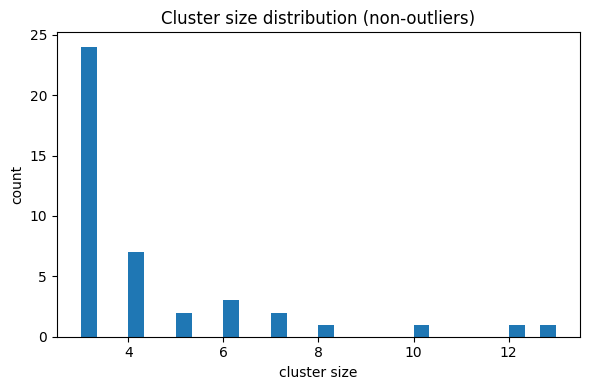

In [ ]:
def label_scenes(dataset: str, image_ids: List[str], clusters: List[List[str]], outliers: set) -> pd.DataFrame:
    def cluster_key(c: List[str]):
        c_sorted = sorted(c)
        return (-len(c_sorted), c_sorted[0])

    clusters_sorted = sorted([sorted(c) for c in clusters], key=cluster_key)

    scene_of = {}
    for idx, c in enumerate(clusters_sorted, start=1):
        scene = f"cluster_{idx:04d}"
        for im in c:
            scene_of[im] = scene

    for im in image_ids:
        if im in outliers or im not in scene_of:
            scene_of[im] = "outliers"

    out = pd.DataFrame({"dataset": dataset, "image_id": image_ids})
    out["scene"] = out["image_id"].map(scene_of)
    return out


def cluster_size_hist(sizes: List[int]) -> Dict[int, int]:
    h: Dict[int, int] = {}
    for s in sizes:
        h[int(s)] = h.get(int(s), 0) + 1
    return dict(sorted(h.items(), key=lambda x: x[0]))


def run_dataset(dataset: str) -> Tuple[pd.DataFrame, dict]:
    df = images_df[images_df["dataset"] == dataset].reset_index(drop=True)
    image_ids = df["image_id"].tolist()

    emb, _meta = get_embeddings(images_df, dataset)
    pairs = get_or_build_pairs(dataset, emb)

    matcher = create_local_matcher()
    print(f"Local matcher [{dataset}]: {type(matcher).__name__}")

    stats = compute_pair_stats_for_dataset(images_df, dataset, pairs, matcher)
    G0, info = build_verified_graph(images_df, dataset, stats)
    G = prune_graph_top_m(G0, TOP_M_EDGES)

    outliers_graph = compute_outliers(G)

    clusters = cluster_graph(G, CLUSTER_METHOD, RANDOM_SEED)
    clusters = maybe_split_huge_clusters(G, clusters, RANDOM_SEED)

    clusters, out_small = postprocess_clusters(clusters, MIN_CLUSTER_SIZE)
    outliers = set(outliers_graph) | set(out_small)

    df_out = label_scenes(dataset, image_ids, clusters, outliers)

    sizes = [len(c) for c in clusters]
    summary = {
        "dataset": dataset,
        "n_images": len(image_ids),
        "n_clusters": len(clusters),
        "n_outliers": int((df_out["scene"] == "outliers").sum()),
        "cluster_size_hist": cluster_size_hist(sizes),
        "edges_candidate": info["edges_candidate"],
        "edges_verified": info["edges_verified"],
        "edges_after_prune": int(G.number_of_edges()),
    }
    return df_out, summary


all_outputs = []
summaries = []

for dataset in sorted(datasets.keys()):
    out_df, summary = run_dataset(dataset)
    all_outputs.append(out_df)
    summaries.append(summary)

clusters_df = pd.concat(all_outputs, ignore_index=True)

ensure_dir(CACHE_ROOT)
clusters_path = CACHE_ROOT / "clusters.csv"
clusters_df.to_csv(clusters_path, index=False)

display(clusters_df.head())
print("Saved:", clusters_path)

for s in summaries:
    print()
    print("==", s["dataset"], "==")
    print("N images:", s["n_images"])
    print("#clusters:", s["n_clusters"], "  #outliers:", s["n_outliers"])
    print("Edges: candidates=", s["edges_candidate"], " verified=", s["edges_verified"], " after_prune=", s["edges_after_prune"])
    print("Rescue pairs added:", s.get("rescue_pairs_added", 0))
    print("Cluster size histogram:", s["cluster_size_hist"])

if plt is not None:

    sizes = clusters_df[clusters_df["scene"].ne("outliers")].groupby(["dataset", "scene"]).size().values
    plt.figure(figsize=(6, 4))
    plt.hist(sizes, bins=30)
    plt.title("Cluster size distribution (non-outliers)")
    plt.xlabel("cluster size")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


### Quick visual check

Showing a small grid (first 9 images) for a few clusters can sanity-check clustering quality.


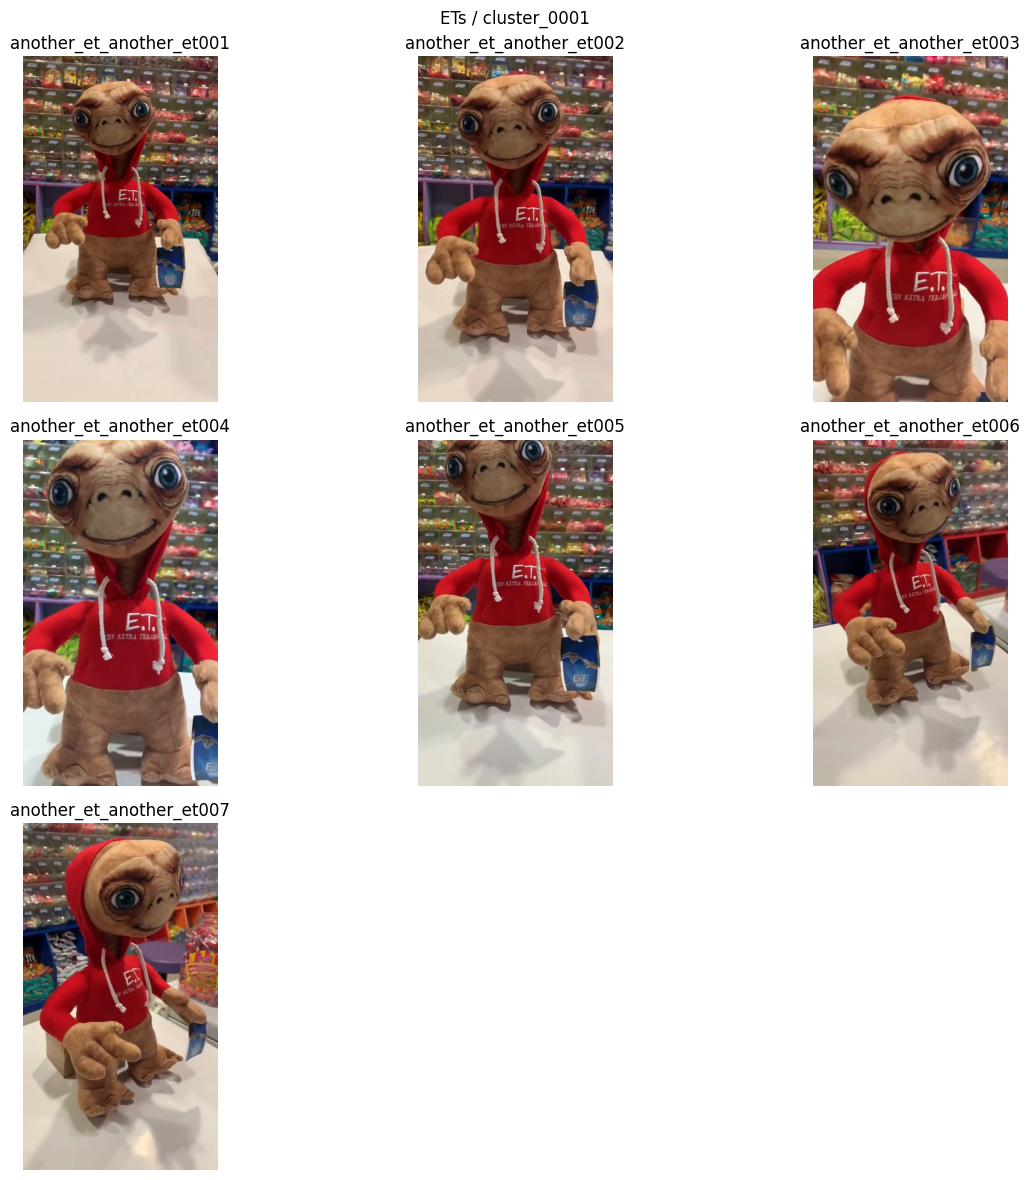

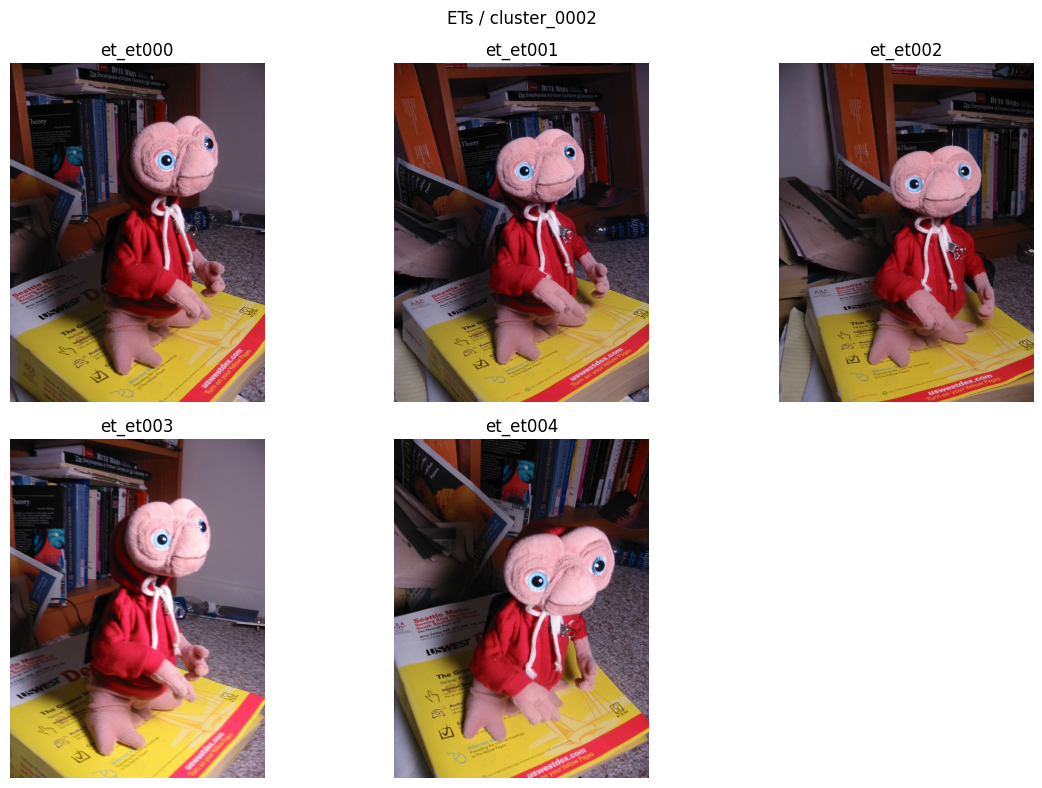

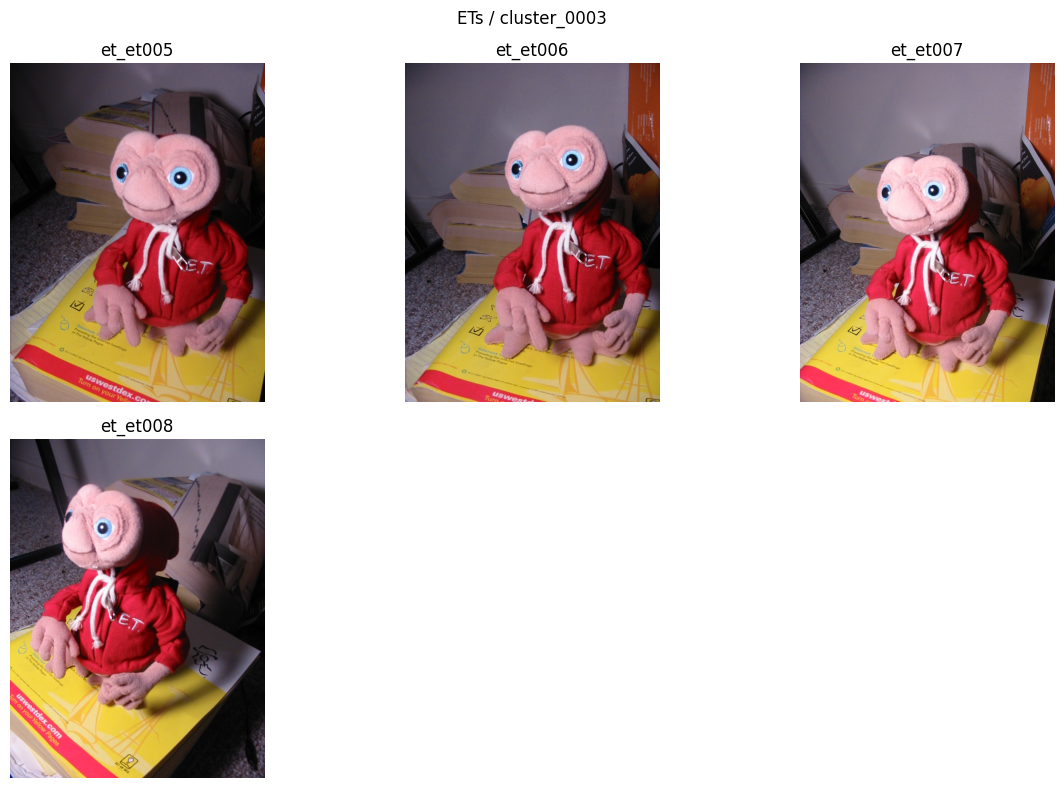

In [59]:
def show_cluster_grid(dataset: str, scene: str, max_images: int = 9):
    if plt is None:
        print("matplotlib not available")
        return

    df = images_df[images_df["dataset"] == dataset].reset_index(drop=True)
    ids = clusters_df[(clusters_df["dataset"] == dataset) & (clusters_df["scene"] == scene)]["image_id"].tolist()
    if not ids:
        print("No images for", dataset, scene)
        return
    ids = ids[:max_images]

    id_to_path = dict(zip(df["image_id"].tolist(), df["path"].tolist()))

    n = len(ids)
    cols = 3
    rows = int(math.ceil(n / cols))
    plt.figure(figsize=(cols * 4, rows * 4))
    for k, image_id in enumerate(ids, start=1):
        path = id_to_path.get(image_id)
        if path is None:
            continue
        img = load_pil_rgb_exif_fixed(path)
        plt.subplot(rows, cols, k)
        plt.imshow(img)
        plt.title(image_id)
        plt.axis("off")
    plt.suptitle(f"{dataset} / {scene}")
    plt.tight_layout()
    plt.show()


first_ds = sorted(datasets.keys())[0]
top_scenes = (
    clusters_df[(clusters_df["dataset"] == first_ds) & (clusters_df["scene"] != "outliers")]
    .groupby("scene")
    .size()
    .sort_values(ascending=False)
    .head(3)
    .index
    .tolist()
)

for sc in top_scenes:
    show_cluster_grid(first_ds, sc, max_images=9)


## Next step: SfM per cluster

The `clusters.csv` produced here can be used to run SfM independently per scene:
- group images by `(dataset, scene)`
- for each cluster, run feature extraction/matching and incremental reconstruction with `pycolmap`/COLMAP
- smaller, cleaner clusters improve reconstruction success and reduce runtime

This notebook intentionally stops at clustering and does **not** estimate camera poses.
